In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

print("Notebook setup complete ✅")

Notebook setup complete ✅


In [2]:
# Step 3.1: Define sensor data schema

SCHEMA = {
    "timestamp": "datetime",
    "lat": "float",
    "lon": "float",
    "speed_kmh": "float",
    "accel_z": "float"
}

pd.DataFrame(columns=SCHEMA.keys())

,timestamp,lat,lon,speed_kmh,accel_z


In [3]:
# Step 3.2: Simulate road sensor data

def simulate_road_data(road_name, samples, speed_kmh, accel_std):
    timestamps = pd.date_range(
        start="2026-01-01",
        periods=samples,
        freq="100ms"
    )

    data = pd.DataFrame({
        "timestamp": timestamps,
        "lat": -26.2 + np.random.normal(0, 0.0001, samples),
        "lon": 28.0 + np.random.normal(0, 0.0001, samples),
        "speed_kmh": speed_kmh,
        "accel_z": np.random.normal(0, accel_std, samples)
    })

    data["road"] = road_name
    return data

In [4]:
# Step 3.3: Generate smooth and rough road data

smooth_road = simulate_road_data(
    road_name="Smooth Road",
    samples=1000,
    speed_kmh=60,
    accel_std=0.3
)

rough_road = simulate_road_data(
    road_name="Rough Road",
    samples=1000,
    speed_kmh=60,
    accel_std=1.2
)

df = pd.concat([smooth_road, rough_road])
df.head()

,timestamp,lat,lon,speed_kmh,accel_z,road
0,2026-01-01 00:00:00.000,-26.199950,28.000140,60,-0.202553,Smooth Road
1,2026-01-01 00:00:00.100,-26.200014,28.000092,60,-0.043356,Smooth Road
2,2026-01-01 00:00:00.200,-26.199935,28.000006,60,-0.237726,Smooth Road
3,2026-01-01 00:00:00.300,-26.199848,27.999935,60,-0.092388,Smooth Road
4,2026-01-01 00:00:00.400,-26.200023,28.000070,60,-0.568084,Smooth Road


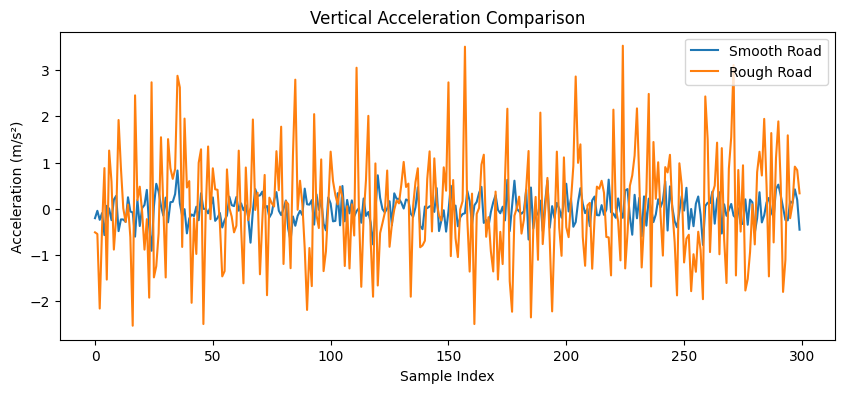

In [5]:
# Step 3.4: Visualize vertical acceleration differences

plt.figure(figsize=(10, 4))

for road in df["road"].unique():
    subset = df[df["road"] == road]
    plt.plot(subset["accel_z"].values[:300], label=road)

plt.title("Vertical Acceleration Comparison")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration (m/s²)")
plt.legend()
plt.show()

In [6]:
# Step 3.5: Extract wear-related features from sensor data

def extract_features(road_df):
    features = {
        "avg_abs_accel": road_df["accel_z"].abs().mean(),
        "accel_variance": road_df["accel_z"].var(),
        "shock_count": (road_df["accel_z"].abs() > 2.0).sum(),
        "speed_kmh": road_df["speed_kmh"].mean()
    }
    return features

In [7]:
# Step 3.6: Compute Wear Index v1 (0–10)

def compute_wear_index(features):
    roughness_score = features["avg_abs_accel"] * 2
    shock_penalty = features["shock_count"] * 0.01
    speed_factor = features["speed_kmh"] / 50

    raw_score = (roughness_score + shock_penalty) * speed_factor

    wear_index = round(min(raw_score, 10), 2)
    return wear_index

In [8]:
# Step 3.7: Compare Wear Index for each road

results = []

for road in df["road"].unique():
    road_df = df[df["road"] == road]
    features = extract_features(road_df)
    wear_index = compute_wear_index(features)

    results.append({
        "road": road,
        "wear_index": wear_index,
        **features
    })

results_df = pd.DataFrame(results)
results_df

,road,wear_index,avg_abs_accel,accel_variance,shock_count,speed_kmh
0,Smooth Road,0.57,0.235508,0.087046,0,60.0
1,Rough Road,3.59,0.952038,1.461360,109,60.0
